In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
def entropy(y):
    """Calculates the entropy of a label distribution."""
    hist = np.bincount(y)
    ps = hist / len(y)
    return -np.sum([p * np.log2(p) for p in ps if p > 0])

def gini_index(y):
    """Calculates the Gini impurity (optional alternative to entropy)."""
    hist = np.bincount(y)
    ps = hist / len(y)
    return 1 - np.sum(ps**2)

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None, splitter_type='best'):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.splitter_type = splitter_type
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(self.n_features, X.shape[1])
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Select features to consider (random subset for RF/Extra Trees)
        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Find the best split
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        # If no valid split found, make it a leaf
        if best_feat is None:
            return Node(value=self._most_common_label(y))

        # Create children
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)

        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]

            # Logic for Extra Trees vs Standard Decision Tree/RF
            if self.splitter_type == 'random':
                # Extra Trees: Pick ONE random split point per feature [cite: 18]
                min_val, max_val = np.min(X_column), np.max(X_column)
                if min_val == max_val: continue
                thresholds = [np.random.uniform(min_val, max_val)]
            else:
                # Standard DT/RF: Check ALL unique values to find optimum
                thresholds = np.unique(X_column)

            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thr

        return split_idx, split_thresh

    def _information_gain(self, y, X_column, threshold):
        # Parent entropy
        parent_entropy = entropy(y)

        # Generate split
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # Weighted avg child entropy
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = entropy(y[left_idxs]), entropy(y[right_idxs])
        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r

        # Information Gain
        ig = parent_entropy - child_entropy
        return ig

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [ ]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, n_features=None, trees_type='standard'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.trees_type = trees_type
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            # 1. Random Forest uses Bootstrapping
            # 2. Extra Trees usually uses the whole dataset (no bootstrap)
            if self.trees_type == 'standard':
                X_sample, y_sample = self._bootstrap_sample(X, y)
                splitter = 'best'
            else:
                X_sample, y_sample = X, y # Extra Trees often uses full set
                splitter = 'random' # Key difference: Random split points

            tree = DecisionTree(
                min_samples_split=self.min_samples_split,
                max_depth=self.max_depth,
                n_features=self.n_features,
                splitter_type=splitter
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        predictions = [Counter(tree_pred).most_common(1)[0][0] for tree_pred in tree_preds]
        return np.array(predictions)

# Wrapper specifically for Extra Trees naming convention
class ExtraTrees(RandomForest):
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, n_features=None):
        super().__init__(n_trees, max_depth, min_samples_split, n_features, trees_type='extra')

In [ ]:
from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.ensemble import RandomForestClassifier as SkRF, ExtraTreesClassifier as SkET

def evaluate_model(model, X_train, X_test, y_train, y_test, multi_class='ovr'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    # AUROC handling for multiclass
    try:
        lb = LabelBinarizer()
        lb.fit(y_train)
        y_test_bin = lb.transform(y_test)
        y_pred_bin = lb.transform(y_pred)
        roc = roc_auc_score(y_test_bin, y_pred_bin, multi_class=multi_class)
    except ValueError:
        roc = 0.0 # Handle cases where ROC might fail on small subsets

    return acc, f1, roc

def run_experiment(dataset_name):
    print(f"\n--- Running Experiment on {dataset_name.upper()} Dataset ---")

    if dataset_name == 'iris':
        data = load_iris()
    else:
        data = load_wine()

    X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

    params = {
        'max_depth': 5,
        'min_samples_split': 2,
        'n_features': int(np.sqrt(X.shape[1]))
    }
    rf_params = {**params, 'n_trees': 10}

    # 2. Define Models
    models = {
        "Custom DT": DecisionTree(**params),
        "Sklearn DT": SkDT(max_depth=params['max_depth'], min_samples_split=params['min_samples_split'], random_state=RANDOM_SEED),

        "Custom RF": RandomForest(**rf_params),
        "Sklearn RF": SkRF(n_estimators=10, max_depth=params['max_depth'], random_state=RANDOM_SEED),

        "Custom ET": ExtraTrees(**rf_params),
        "Sklearn ET": SkET(n_estimators=10, max_depth=params['max_depth'], random_state=RANDOM_SEED)
    }

    # 3. Train and Evaluate
    results = []
    for name, model in models.items():
        acc, f1, roc = evaluate_model(model, X_train, X_test, y_train, y_test)
        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1-Score": f1,
            "AUROC": roc
        })

    # 4. Show Results Table [cite: 54]
    results_df = pd.DataFrame(results)
    print(results_df)
    return results_df

df_iris = run_experiment('iris')
df_wine = run_experiment('wine')


--- Running Experiment on IRIS Dataset ---
        Model  Accuracy  F1-Score  AUROC
0   Custom DT       1.0       1.0    1.0
1  Sklearn DT       1.0       1.0    1.0
2   Custom RF       1.0       1.0    1.0
3  Sklearn RF       1.0       1.0    1.0
4   Custom ET       1.0       1.0    1.0
5  Sklearn ET       1.0       1.0    1.0

--- Running Experiment on WINE Dataset ---
        Model  Accuracy  F1-Score     AUROC
0   Custom DT  0.861111  0.852053  0.886364
1  Sklearn DT  0.944444  0.942474  0.952110
2   Custom RF  0.972222  0.968046  0.982143
3  Sklearn RF  0.972222  0.966284  0.971591
4   Custom ET  0.972222  0.968046  0.982143
5  Sklearn ET  0.972222  0.968046  0.982143


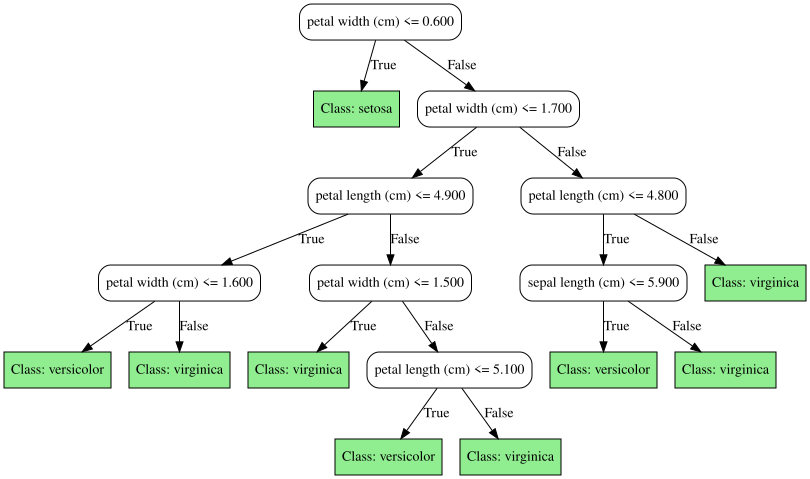

In [ ]:
from graphviz import Digraph

def visualize_custom_tree(tree, feature_names=None, class_names=None):
    if tree.root is None:
        print("Tree is empty!")
        return None

    dot = Digraph(comment='Decision Tree')
    dot.attr(rankdir='TB')

    def add_node(node, node_id):
        if node.is_leaf_node():
            class_label = node.value
            if class_names is not None:
                try:
                    class_label = class_names[int(node.value)]
                except:
                    class_label = str(node.value)

            label_str = f"Class: {class_label}"
            dot.node(node_id, label=label_str, shape='box',
                     style='filled', fillcolor='#90EE90')
            return

        if feature_names is not None:
            feature_name = feature_names[node.feature]
        else:
            feature_name = f"Feature {node.feature}"

        label_str = f"{feature_name} <= {node.threshold:.3f}"
        dot.node(node_id, label=label_str, shape='box', style='rounded')

        left_id = f"{node_id}L"
        right_id = f"{node_id}R"
        dot.edge(node_id, left_id, label="True")
        dot.edge(node_id, right_id, label="False")

        add_node(node.left, left_id)
        add_node(node.right, right_id)
    add_node(tree.root, "root")
    return dot

iris = load_iris()
X, y = iris.data, iris.target

viz_model = DecisionTree(max_depth=5, min_samples_split=2)
viz_model.fit(X, y)

dot = visualize_custom_tree(viz_model, iris.feature_names, iris.target_names)

dot

IndexError: list index out of range

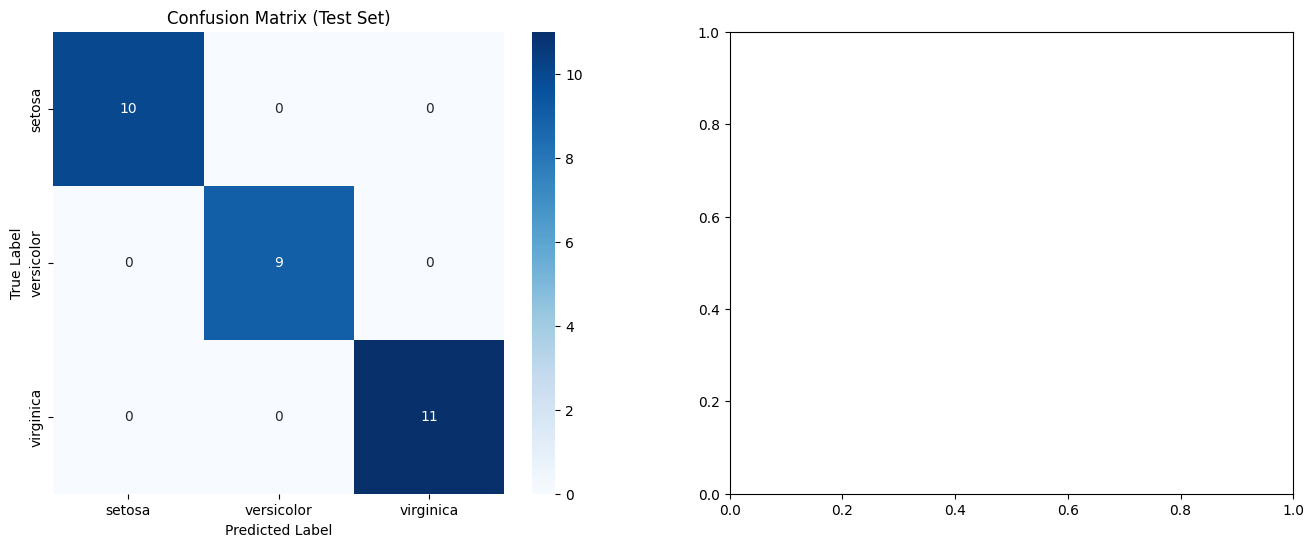

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

def visualize_performance(model_class, X, y, feature_names, target_names):
    # 1. Train/Test Split
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Train the Random Forest
    rf = model_class(n_trees=10, max_depth=5)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    # Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot A: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=target_names, yticklabels=target_names)
    axes[0].set_title('Confusion Matrix (Test Set)')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # --- Plot B: Decision Boundaries (2D) ---
    # We pick the two most important features (Index 2 & 3 for Iris usually)
    f1, f2 = 2, 3
    X_pair = X[:, [f1, f2]]

    # Train a new generic model on just these 2 features for visualization
    rf_2d = model_class(n_trees=10, max_depth=5)
    rf_2d.fit(X_pair, y)

    # Create a meshgrid
    x_min, x_max = X_pair[:, 0].min() - 0.5, X_pair[:, 0].max() + 0.5
    y_min, y_max = X_pair[:, 1].min() - 0.5, X_pair[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # Predict across the meshgrid
    Z = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contours
    cmap_light = ListedColormap(['#FFCCCC', '#CCFFCC', '#CCCCFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

    axes[1].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    sns.scatterplot(x=X_pair[:, 0], y=X_pair[:, 1], hue=target_names[y],
                    palette={'setosa': '#FF0000', 'versicolor': '#00AA00', 'virginica': '#0000FF'},
                    edgecolor="black", s=60, ax=axes[1])

    axes[1].set_title(f'Decision Region ({feature_names[f1]} vs {feature_names[f2]})')
    axes[1].set_xlabel(feature_names[f1])
    axes[1].set_ylabel(feature_names[f2])

    plt.tight_layout()
    plt.show()

# --- Run the Visualization ---
from sklearn.datasets import load_iris
data = load_iris()

# Pass your RandomForest class here
visualize_performance(RandomForest, data.data, data.target, data.feature_names, data.target_names)